# OSM API Python

Trying out this example (https://pygis.io/docs/d_access_osm.html) to get querying OSM given a polygon.

In [ ]:
import osmnx as ox
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx
import numpy as np
import time
import pandas as pd
from tqdm import tqdm

In [5]:
tags = {'amenity' : 'restaurant'}

london_sample = ox.features_from_place("Greater London", tags).sample(500)
berlin_sample = ox.features_from_place("Berlin, Germany", tags).sample(500)

print(london_sample.head(n=5))
print(berlin_sample.head(n=5))

                                      geometry     amenity  \
element id                                                   
node    899436761     POINT (-0.1911 51.52078)  restaurant   
        6804177166     POINT (-0.122 51.49072)  restaurant   
        1252535360   POINT (-0.16297 51.46446)  restaurant   
        11947939054  POINT (-0.20806 51.60603)  restaurant   
        9727068543    POINT (0.07452 51.50552)  restaurant   

                                   name addr:city addr:housenumber  \
element id                                                           
node    899436761          Lime Cuisine    London              108   
        6804177166           TDQ Steaks    London               25   
        1252535360            Song Hong    London              180   
        11947939054      Day of the Raj    London               15   
        9727068543   Café Spice Namasté    London              1-2   

                    addr:postcode        addr:street  bar     cuisine  \
e

In [6]:
london_sample.to_file("london_osm_sample.geojson")
berlin_sample.to_file("berlin_osm_sample.geojson")

<Axes: >

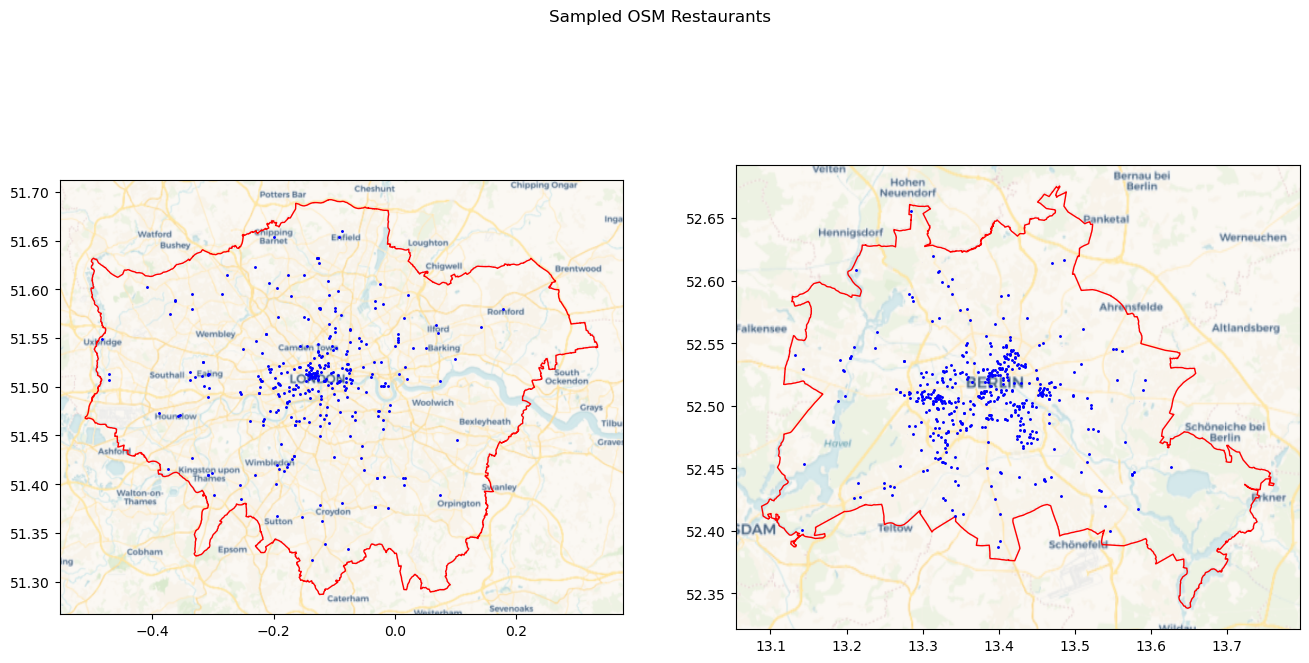

In [11]:
fig, axs = plt.subplots(1,2, figsize=(16,8))

london = gpd.read_file("london_4326.geojson")
berlin = gpd.read_file("berlin_4326.geojson")

fig.suptitle("Sampled OSM Restaurants")

london.plot(ax=axs[0], edgecolor='red', facecolor='none')
cx.add_basemap(ax=axs[0], crs='EPSG:4326', attribution=False, source=cx.providers.CartoDB.Voyager)

berlin.plot(ax=axs[1], edgecolor='red', facecolor='none')
cx.add_basemap(ax=axs[1], crs='EPSG:4326', attribution=False, source=cx.providers.CartoDB.Voyager)


london_sample.plot(ax=axs[0], color='blue', markersize=1.2)
berlin_sample.plot(ax=axs[1], color='blue', markersize=1.2)
